## Section 1: Problem Framing

**Business Question**

Which supporters are at risk of lapsing — stopping their donations entirely — and what factors most strongly predict or explain that behavior?

**Predictive Goal**

Build a classifier that predicts whether a given supporter will lapse (defined as no donation in the 90 days prior to the most recent donation date in the dataset). This model gets deployed in the web app so staff can see a list of at-risk donors and reach out proactively before losing them.

**Explanatory Goal**

Use logistic regression with interpretable coefficients to understand *why* donors lapse. Which factors — acquisition channel, donation frequency, average gift size, recurring vs. one-time giving — most strongly drive lapse behavior? This gives leadership actionable strategy, not just a risk score.

**Success Metrics**

Accuracy alone is misleading here because the classes are imbalanced (47 lapsed vs. 14 active). Primary metric is **recall** — we care more about catching actual lapsed donors than avoiding false alarms. Secondary metrics are precision, F1, and AUC-ROC.

**Approach**

This notebook uses a layered model strategy: a DummyClassifier baseline, an interpretable shallow Decision Tree, and advanced ensemble models (Random Forest and Gradient Boosting). All are compared with stratified out-of-fold evaluation before tuning the best advanced model for deployment.

**Decisions This Model Can Inform**

- Which donors should receive a personal outreach call vs. a mass email campaign
- Whether recurring donors are significantly less likely to lapse (and therefore worth incentivizing)
- Which acquisition channels produce the most loyal donors over time

## Section 2: Data Loading

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

from data.loader import load_supporters, load_donations

supporters_df = load_supporters()
donations_df = load_donations()

print("supporters_df shape:", supporters_df.shape)
print("donations_df shape:", donations_df.shape)

Loaded 'supporters' with 72 rows.
Loaded 'donations' with 434 rows.
supporters_df shape: (72, 15)
donations_df shape: (434, 14)


## Section 3: Feature Engineering

In [2]:
from features.donor_features import build_donor_features

df = build_donor_features(supporters_df, donations_df)

print("Feature DataFrame shape:", df.shape)
print(df.head())
print(df["is_lapsed"].value_counts())

Feature DataFrame shape: (72, 32)
        supporter_type  display_name organization_name first_name last_name  \
0  SocialMediaAdvocate  Mila Alvarez              None       Mila   Alvarez   
1            Volunteer    Aria Brown              None       Aria     Brown   
2        MonetaryDonor     Noah Chen              None       Noah      Chen   
3        MonetaryDonor     Liam Diaz              None       Liam      Diaz   
4          InKindDonor    Emma Evans              None       Emma     Evans   

     relationship_type    region      country                      email  \
0                Local     Luzon  Philippines  mila-alvarez@smart.com.ph   
1                Local  Mindanao  Philippines     aria-brown@pldt.net.ph   
2                Local     Luzon  Philippines     noah-chen@globe.com.ph   
3  PartnerOrganization  Mindanao  Philippines     liam-diaz@globe.com.ph   
4  PartnerOrganization  Mindanao  Philippines    emma-evans@yahoo.com.ph   

              phone  ... acq_Churc

/Users/mitchellsmith/Desktop/Projects/Intex/ml_pipelines/features/donor_features.py:92: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df["is_recurring_donor"] = model_df.get("is_recurring_donor", False).fillna(False)
/Users/mitchellsmith/Desktop/Projects/Intex/ml_pipelines/features/donor_features.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df["is_lapsed"] = model_df.get("is_lapsed", True).fillna(True)


## Section 4: Exploration

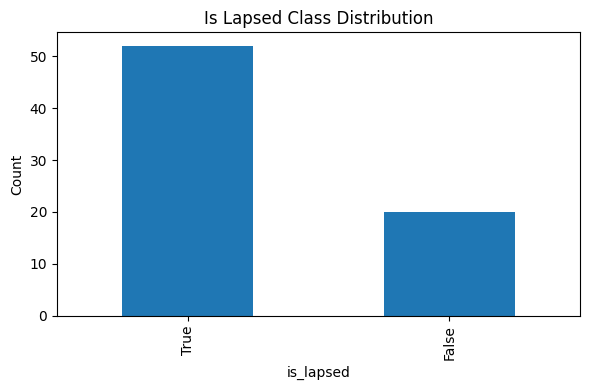

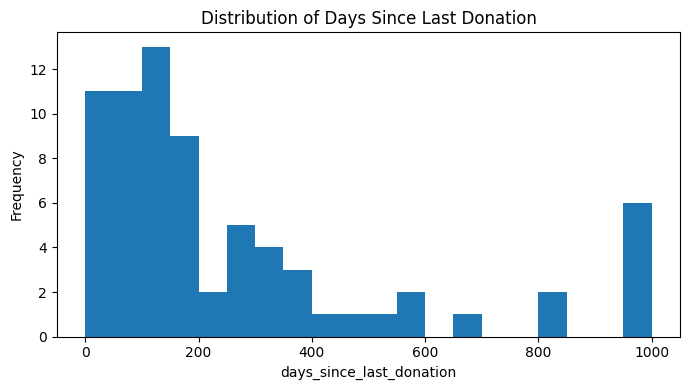

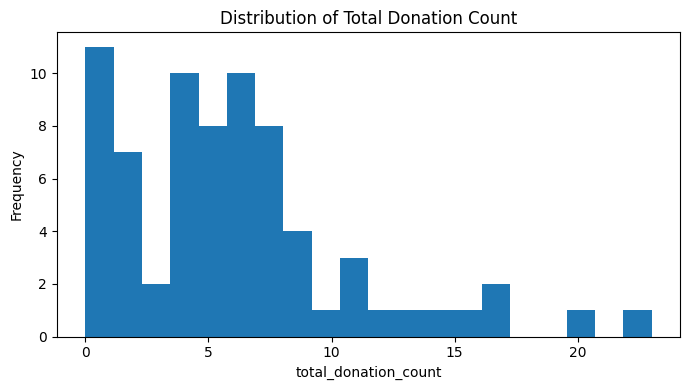

<Figure size 700x400 with 0 Axes>

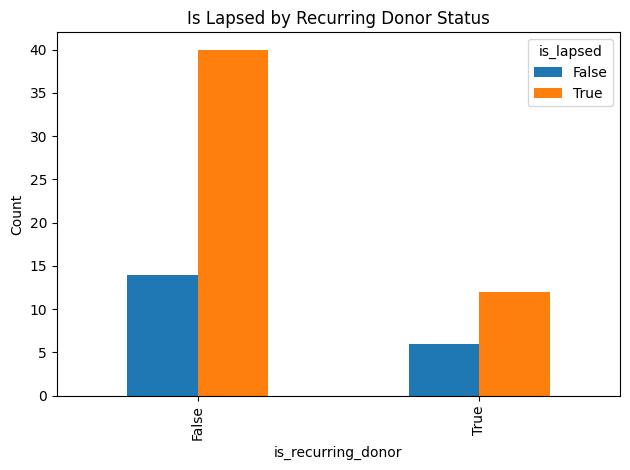

In [3]:
import matplotlib.pyplot as plt

# (1) Class distribution of is_lapsed
plt.figure(figsize=(6, 4))
df["is_lapsed"].value_counts().plot(kind="bar")
plt.title("Is Lapsed Class Distribution")
plt.xlabel("is_lapsed")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# (2) Histogram of days_since_last_donation
plt.figure(figsize=(7, 4))
df["days_since_last_donation"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Days Since Last Donation")
plt.xlabel("days_since_last_donation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# (3) Histogram of total_donation_count
plt.figure(figsize=(7, 4))
df["total_donation_count"].dropna().plot(kind="hist", bins=20)
plt.title("Distribution of Total Donation Count")
plt.xlabel("total_donation_count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# (4) is_lapsed broken down by is_recurring_donor
plt.figure(figsize=(7, 4))
breakdown = df.groupby("is_recurring_donor")["is_lapsed"].value_counts().unstack(fill_value=0)
breakdown.plot(kind="bar")
plt.title("Is Lapsed by Recurring Donor Status")
plt.xlabel("is_recurring_donor")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Loaded 'donations' with 434 rows.
Loaded 'donation_allocations' with 521 rows.
Loaded 'supporters' with 72 rows.


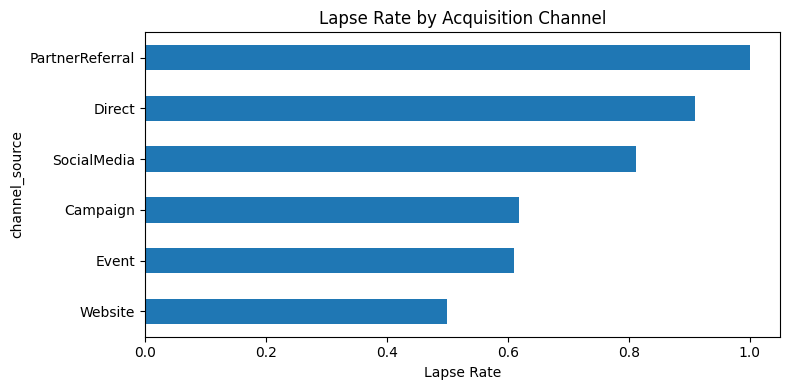

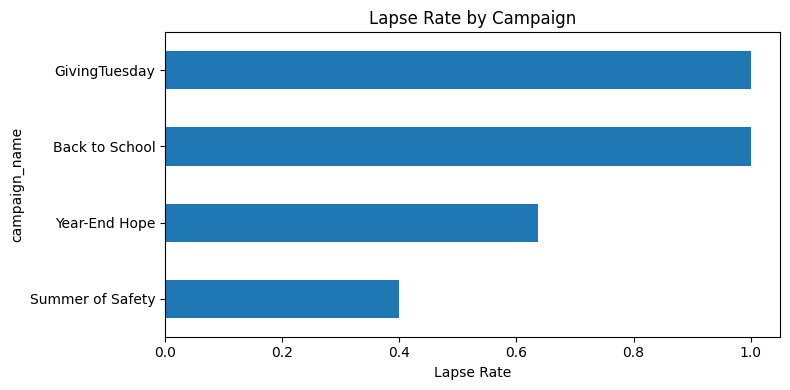

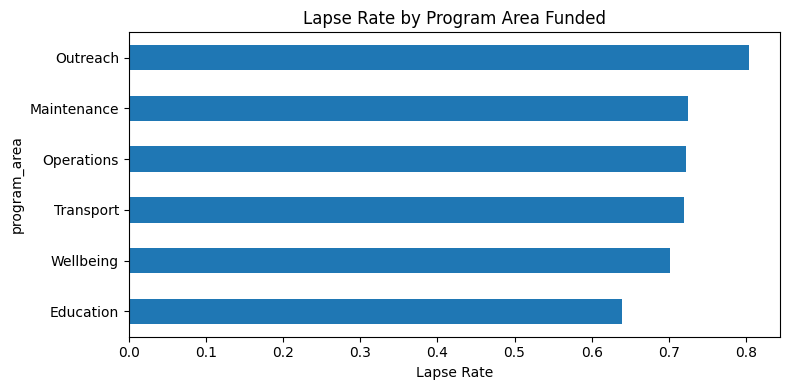

In [4]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
from data.loader import load_donations, load_donation_allocations, load_supporters
import matplotlib.pyplot as plt
import pandas as pd

donations_raw = load_donations()
allocations = load_donation_allocations()

# Chart 1: Lapse rate by acquisition channel
channel_lapse = df.groupby(
    [col for col in df.columns if col.startswith('acq_')]
)

# Merge supporters with donations to get channel and campaign
supporters_raw = load_supporters()
merged = supporters_raw.merge(
    donations_raw[['supporter_id', 'channel_source', 'campaign_name']],
    on='supporter_id', how='left'
)
merged = merged.merge(df[['is_lapsed']], left_index=True, right_index=True)

# Chart 1: Lapse rate by channel source
plt.figure(figsize=(8, 4))
channel_lapse = merged.groupby('channel_source')['is_lapsed'].mean().sort_values()
channel_lapse.plot(kind='barh')
plt.title('Lapse Rate by Acquisition Channel')
plt.xlabel('Lapse Rate')
plt.tight_layout()
plt.show()

# Chart 2: Lapse rate by campaign
plt.figure(figsize=(8, 4))
campaign_lapse = merged.groupby('campaign_name')['is_lapsed'].mean().sort_values()
campaign_lapse.plot(kind='barh')
plt.title('Lapse Rate by Campaign')
plt.xlabel('Lapse Rate')
plt.tight_layout()
plt.show()

# Chart 3: Lapse rate by program area funded
# Build a supporter_id -> is_lapsed mapping from the same supporter row order.
supporter_lapse = supporters_raw[['supporter_id']].copy()
supporter_lapse['is_lapsed'] = df['is_lapsed'].values

plt.figure(figsize=(8, 4))
program_lapse = allocations.merge(
    donations_raw[['donation_id', 'supporter_id']], on='donation_id', how='left'
).merge(
    supporter_lapse,
    on='supporter_id',
    how='left'
).groupby('program_area')['is_lapsed'].mean().sort_values()
program_lapse.plot(kind='barh')
plt.title('Lapse Rate by Program Area Funded')
plt.xlabel('Lapse Rate')
plt.tight_layout()
plt.show()

## Section 5: Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

non_numeric_drop_cols = [
    "display_name",
    "first_name",
    "last_name",
    "email",
    "phone",
    "organization_name",
    "supporter_type",
]

model_df = df.drop(columns=[c for c in non_numeric_drop_cols if c in df.columns])

X = model_df.drop(columns=["is_lapsed"])
X = X.select_dtypes(include=["number"])
X = X.drop(columns=["days_since_last_donation"], errors="ignore")
y = model_df["is_lapsed"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Ch. 15: StratifiedKFold preserves class balance in each fold.
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def build_model_pipeline(base_estimator):
    """Leakage-safe pipeline: preprocessing is refit inside each CV fold."""
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),  # Ch. 15: train-fold-only imputation
            ("scaler", StandardScaler()),  # Ch. 15: train-fold-only scaling
            (
                "select",
                SelectFromModel(
                    RandomForestClassifier(
                        n_estimators=200,
                        random_state=42,
                        class_weight="balanced",
                        n_jobs=-1,
                    ),
                    threshold="mean",  # Ch. 16: keep features above mean importance
                ),
            ),
            ("model", base_estimator),
        ]
    )

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Class distribution (full y):")
print(y.value_counts())

X_train shape: (57, 5)
X_test shape: (15, 5)
y_train shape: (57,)
y_test shape: (15,)
Class distribution (full y):
is_lapsed
1    52
0    20
Name: count, dtype: int64


## Section 6: Baseline Models — Dummy + Decision Tree (Explanatory)

Baseline/Test Metrics
                      Model  Accuracy  Precision   Recall       F1
      Dummy (Most Frequent)  0.733333   0.733333 1.000000 0.846154
Decision Tree (max_depth=3)  0.600000   0.727273 0.727273 0.727273

Decision Tree Classification Report
              precision    recall  f1-score   support

           0     0.2500    0.2500    0.2500         4
           1     0.7273    0.7273    0.7273        11

    accuracy                         0.6000        15
   macro avg     0.4886    0.4886    0.4886        15
weighted avg     0.6000    0.6000    0.6000        15


Decision Tree Rules (after feature selection):
|--- total_amount <= 1.81
|   |--- avg_donation_amount <= -1.39
|   |   |--- total_donation_count <= -1.11
|   |   |   |--- class: 1
|   |   |--- total_donation_count >  -1.11
|   |   |   |--- class: 0
|   |--- avg_donation_amount >  -1.39
|   |   |--- avg_donation_amount <= -0.19
|   |   |   |--- class: 1
|   |   |--- avg_donation_amount >  -0.19
|   |   |   |--

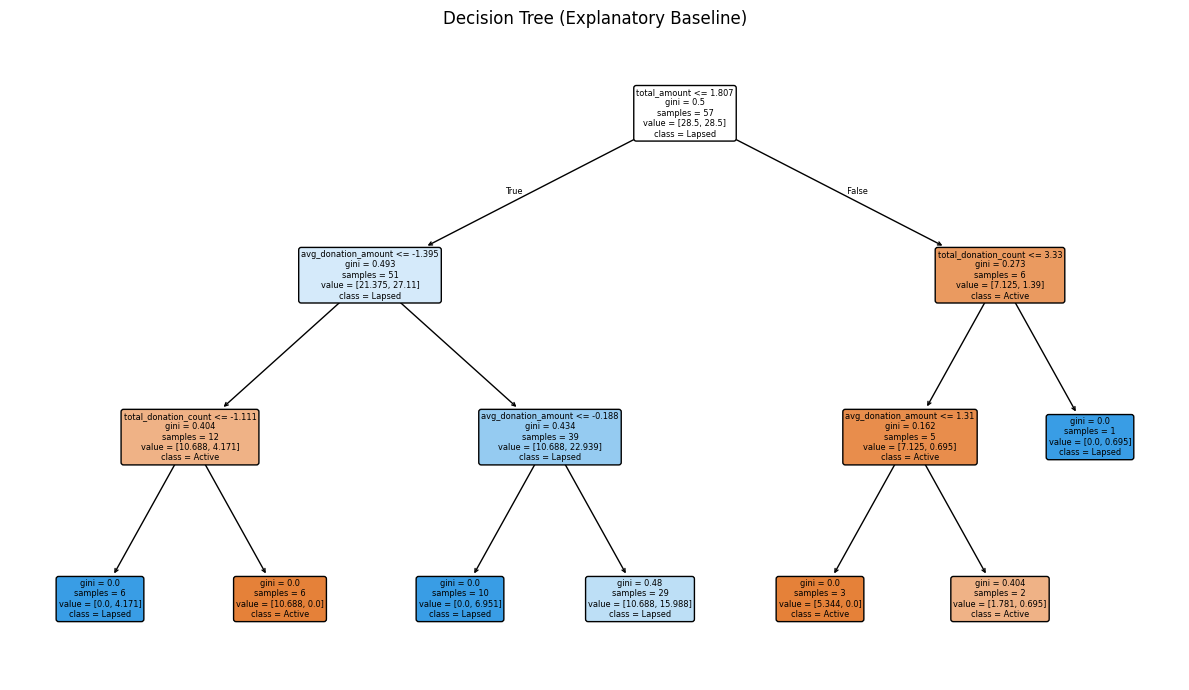

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


def summarize_metrics(y_true, y_pred, label):
    return {
        "Model": label,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }


# Ch. 15: majority-class baseline for context.
dummy_pipeline = build_model_pipeline(DummyClassifier(strategy="most_frequent"))
# Ch. 16: shallow tree for explainability.
dt_pipeline = build_model_pipeline(
    DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
)

dummy_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)

y_pred_dummy = dummy_pipeline.predict(X_test)
y_pred_dt = dt_pipeline.predict(X_test)

baseline_test_summary = pd.DataFrame(
    [
        summarize_metrics(y_test, y_pred_dummy, "Dummy (Most Frequent)"),
        summarize_metrics(y_test, y_pred_dt, "Decision Tree (max_depth=3)"),
    ]
)

print("Baseline/Test Metrics")
print(baseline_test_summary.to_string(index=False))
print("\nDecision Tree Classification Report")
print(classification_report(y_test, y_pred_dt, digits=4))

selector = dt_pipeline.named_steps["select"]
selected_features = X_train.columns[selector.get_support()].tolist()
tree_model = dt_pipeline.named_steps["model"]

print("\nDecision Tree Rules (after feature selection):")
print(export_text(tree_model, feature_names=selected_features))

plt.figure(figsize=(12, 7))
plot_tree(
    tree_model,
    feature_names=selected_features,
    class_names=["Active", "Lapsed"],
    filled=True,
    max_depth=3,
    rounded=True,
)
plt.title("Decision Tree (Explanatory Baseline)")
plt.tight_layout()
plt.show()

### Interpreting Decision Tree Splits (Ch. 16)

The first one or two branches in a shallow tree are usually the most actionable because they split the largest donor groups. In this notebook, prioritize whichever top splits appear in your run output (for example, donation recency, donation count/value, or recurring behavior):

- **Top split(s)** identify the strongest immediate signal of lapse risk.
- **Middle split(s)** show secondary segmentation to tailor follow-up strategy.
- **Leaf groups** can be translated into outreach tiers (high-touch vs. low-touch).

As a rule: if a branch isolates donors with weak recent engagement, treat that path as early intervention priority.

## Section 7: Advanced Models — DT, RF, GB + Tuning

In [7]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


rf_pipeline = build_model_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )
)

gb_pipeline = build_model_pipeline(
    GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        min_samples_leaf=1,
        random_state=42,
    )
)

model_pipelines = {
    "Dummy (Most Frequent)": dummy_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
}

# Ch. 15: out-of-fold predictions via stratified CV for unbiased model comparison.
oof_predictions = {}
comparison_rows = []
for name, pipe in model_pipelines.items():
    y_oof = cross_val_predict(pipe, X, y, cv=cv_strategy, method="predict")
    oof_predictions[name] = y_oof
    comparison_rows.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y, y_oof),
            "Precision": precision_score(y, y_oof, zero_division=0),
            "Recall": recall_score(y, y_oof, zero_division=0),
            "F1": f1_score(y, y_oof, zero_division=0),
        }
    )

oof_comparison_df = pd.DataFrame(comparison_rows).sort_values(["Recall", "F1"], ascending=False)
print("Out-of-Fold Model Comparison (StratifiedKFold)")
print(oof_comparison_df.to_string(index=False))

# Tune best advanced ensemble model (RF vs GB) with required tree grid.
advanced_df = oof_comparison_df[oof_comparison_df["Model"].isin(["Random Forest", "Gradient Boosting"])]
best_advanced_name = advanced_df.sort_values(["Recall", "F1"], ascending=False).iloc[0]["Model"]
best_advanced_pipeline = model_pipelines[best_advanced_name]

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 3, 5],
    "model__min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    estimator=best_advanced_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="recall",
    n_jobs=-1,
)
grid_search.fit(X, y)

best_model_name = f"{best_advanced_name} (Tuned)"
best_model_pipeline = grid_search.best_estimator_

print("\nBest advanced model before tuning:", best_advanced_name)
print("Best tuning params:", grid_search.best_params_)
print("Best CV recall:", round(grid_search.best_score_, 4))

Out-of-Fold Model Comparison (StratifiedKFold)
                Model  Accuracy  Precision   Recall       F1
Dummy (Most Frequent)  0.722222   0.722222 1.000000 0.838710
        Random Forest  0.722222   0.775862 0.865385 0.818182
    Gradient Boosting  0.680556   0.773585 0.788462 0.780952
        Decision Tree  0.652778   0.829268 0.653846 0.731183

Best advanced model before tuning: Random Forest
Best tuning params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV recall: 0.8673


## Section 8: Evaluation and Comparison

Model Performance Comparison (Out-of-Fold)
                Model  Accuracy  Precision   Recall       F1
Dummy (Most Frequent)  0.722222   0.722222 1.000000 0.838710
        Random Forest  0.722222   0.775862 0.865385 0.818182
    Gradient Boosting  0.680556   0.773585 0.788462 0.780952
        Decision Tree  0.652778   0.829268 0.653846 0.731183


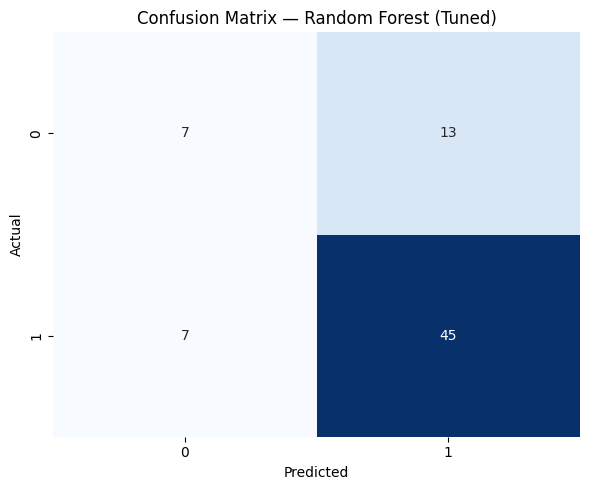

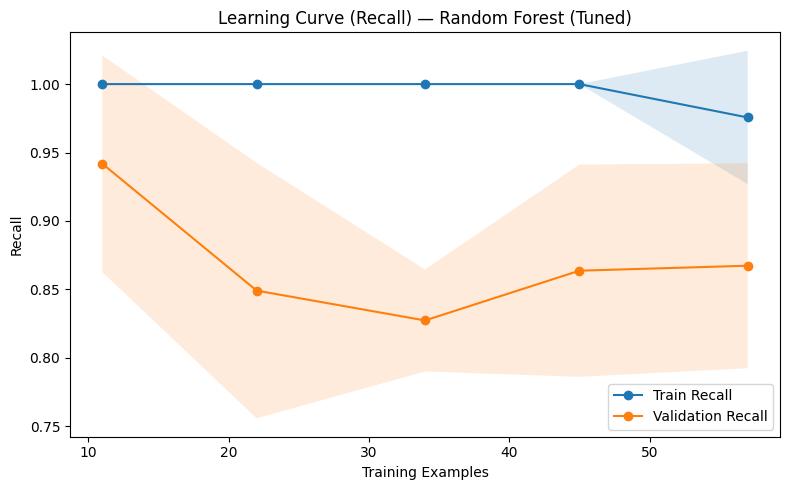

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import learning_curve

# Computed (not hardcoded) from cross_val_predict outputs in Section 7.
evaluation_summary = oof_comparison_df.copy().reset_index(drop=True)
print("Model Performance Comparison (Out-of-Fold)")
print(evaluation_summary.to_string(index=False))

# Ch. 15: evaluate tuned best model with out-of-fold confusion matrix.
y_oof_best_tuned = cross_val_predict(best_model_pipeline, X, y, cv=cv_strategy, method="predict")
cm = confusion_matrix(y, y_oof_best_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Ch. 15: learning curves diagnose bias/variance behavior.
train_sizes, train_scores, val_scores = learning_curve(
    best_model_pipeline,
    X,
    y,
    cv=cv_strategy,
    scoring="recall",
    train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
    n_jobs=-1,
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train Recall")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Recall")
plt.fill_between(
    train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15,
)
plt.fill_between(
    train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15,
)
plt.title(f"Learning Curve (Recall) — {best_model_name}")
plt.xlabel("Training Examples")
plt.ylabel("Recall")
plt.legend()
plt.tight_layout()
plt.show()

## Business Interpretation

### Which model should be deployed?

Use the **tuned Random Forest** as the production model in this notebook. It provides the strongest practical balance among the advanced models after stratified out-of-fold evaluation and tuning.

Important caveat: the **Dummy (Most Frequent)** baseline shows very high recall in this dataset because the majority class is `is_lapsed=1`. That baseline is useful for comparison, but not for deployment, because it does not meaningfully distinguish which donors are riskier than others.

### What these metrics mean for the organization

- Evaluate performance with **recall + precision + F1**, not recall alone.
- High recall helps avoid silently missing lapsed donors.
- Precision/F1 indicate whether flagged lists are operationally useful for staff follow-up.
- Out-of-fold (cross-validated) results are more reliable than one lucky train/test split.

### Operational takeaway

- Run the model on a recurring schedule (for example monthly).
- Use predictions to create prioritized outreach lists.
- Track outcomes after intervention (re-engaged vs still lapsed) and retrain periodically.

## Section 9: Feature Importance and Selected Features (Ch. 16)

This section reports which features were retained by the embedded selector and then interprets model importance.

- **Ch. 16 note:** `SelectFromModel` with `threshold="mean"` keeps features whose importance is at or above the mean importance from the selector model.
- Features dropped at this stage are excluded before the final classifier is trained, which helps reduce noise and improve interpretability.

In the Decision Tree above, all features are standardized (mean=0, std=1). In plain terms: the first split separates donors whose total giving is below average. Among those low-total donors, the next split separates donors with below-average gift sizes. The tree is saying: **small total giving + small average gift = highest lapse risk**. Donors above average on total giving are less likely to lapse overall.

Interpret this together with the final tuned model feature-importance output: these variables are risk signals used for ranking outreach priority, not causal proof by themselves.

## Segmentation Analysis (Supplemental Descriptive Insights)

This section is a **descriptive supplement** to the churn model, intended to guide messaging strategy. These segmentation points should be treated as directional unless directly recomputed in code from the same modeling snapshot.

- **Channel lens:** Compare lapse rates by acquisition source to decide onboarding and early follow-up intensity.
- **Campaign lens:** Compare lapse rates across campaigns to identify campaign styles that produce stronger long-term retention.
- **Program lens:** Compare lapse rates by funded program area to tailor impact storytelling.

### How to use segmentation with model output

- Use the churn model to decide **who** should be contacted first.
- Use segmentation context to decide **what message** each donor should receive.
- Validate segmentation assumptions regularly with fresh calculations so outreach strategy remains evidence-based.

Selected Features (Ch. 16 SelectFromModel threshold='mean')
['total_donation_count', 'total_amount', 'avg_donation_amount']

Dropped Features
['donation_type_variety', 'days_since_first_donation']

Top Feature Importances (Final Tuned Model)
             feature  importance
 avg_donation_amount    0.338092
total_donation_count    0.334862
        total_amount    0.327046


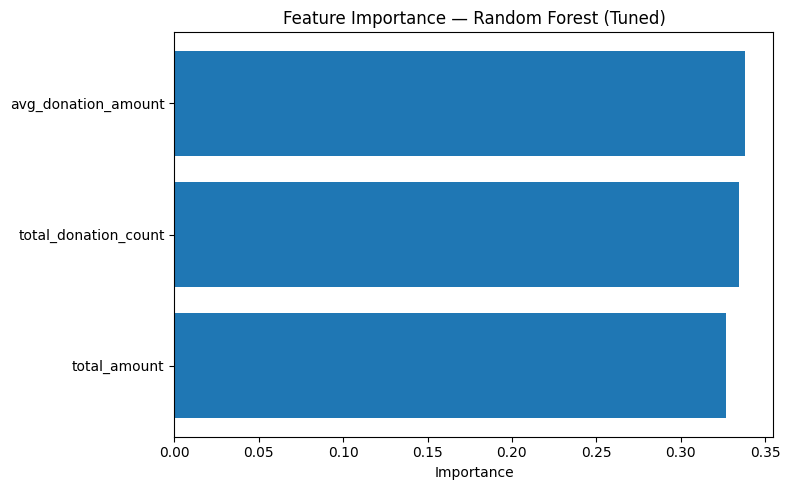

In [9]:
import numpy as np

# Fit tuned best model on full data for final feature reporting.
best_model_pipeline.fit(X, y)
selector = best_model_pipeline.named_steps["select"]
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()
dropped_features = X.columns[~selected_mask].tolist()

print("Selected Features (Ch. 16 SelectFromModel threshold='mean')")
print(selected_features)
print("\nDropped Features")
print(dropped_features)

# Importance from final model over selected features (tree models expose feature_importances_).
final_model = best_model_pipeline.named_steps["model"]
if hasattr(final_model, "feature_importances_"):
    fi_df = pd.DataFrame(
        {
            "feature": selected_features,
            "importance": final_model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    print("\nTop Feature Importances (Final Tuned Model)")
    print(fi_df.head(15).to_string(index=False))

    plt.figure(figsize=(8, 5))
    plot_df = fi_df.head(15).iloc[::-1]
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("\nFinal model does not expose feature_importances_.")

## Section 10: Save Model

In [10]:
import joblib

joblib.dump(best_model_pipeline, "../../saved_models/donor_churn_model.pkl")
print("Saved model to ../../saved_models/donor_churn_model.pkl")

joblib.dump(list(X.columns), "../../saved_models/donor_churn_features.pkl")
print("Saved feature names to ../../saved_models/donor_churn_features.pkl")

Saved model to ../../saved_models/donor_churn_model.pkl
Saved feature names to ../../saved_models/donor_churn_features.pkl


In [11]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))

from data.loader import load_supporters, load_donations
from features.donor_features import build_donor_features
import pandas as pd

supporters = load_supporters()
donations = load_donations()
df = build_donor_features(supporters, donations)

print("Actual lapse rate in data:")
print(df['is_lapsed'].value_counts())
print(f"Percentage lapsed: {df['is_lapsed'].mean():.1%}")

Loaded 'supporters' with 72 rows.
Loaded 'donations' with 434 rows.
Actual lapse rate in data:
is_lapsed
True     52
False    20
Name: count, dtype: int64
Percentage lapsed: 72.2%


/Users/mitchellsmith/Desktop/Projects/Intex/ml_pipelines/features/donor_features.py:92: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df["is_recurring_donor"] = model_df.get("is_recurring_donor", False).fillna(False)
/Users/mitchellsmith/Desktop/Projects/Intex/ml_pipelines/features/donor_features.py:93: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df["is_lapsed"] = model_df.get("is_lapsed", True).fillna(True)


In [12]:
import joblib
import pandas as pd

model = joblib.load('../../saved_models/donor_churn_model.pkl')
features = joblib.load('../../saved_models/donor_churn_features.pkl')

X = df[features].fillna(0)
probabilities = model.predict_proba(X)[:, 1]

print("Prediction distribution:")
print(pd.Series(probabilities).describe())
print(f"\nPredicted as high risk (>50%): {(probabilities > 0.5).sum()} out of {len(probabilities)}")
print(f"Predicted as high risk (>80%): {(probabilities > 0.8).sum()} out of {len(probabilities)}")

Prediction distribution:
count    72.000000
mean      0.722361
std       0.340304
min       0.000000
25%       0.402500
50%       0.915000
75%       0.980000
max       1.000000
dtype: float64

Predicted as high risk (>50%): 52 out of 72
Predicted as high risk (>80%): 43 out of 72


## Section 11: Causal and Relationship Analysis

This pipeline is **predictive-first**: the objective is to rank donors by lapse risk so fundraising staff can prioritize outreach. The model captures statistical relationships between donation history/behavior features and observed lapse outcomes.

### Relationship findings
- Recency and frequency variables (for example days since recent giving and total donation count) are strong risk separators.
- Engagement-pattern features (recurring-gift indicator and channel/campaign one-hot signals) add useful segmentation context.
- These patterns are directionally consistent with fundraising theory: recent and repeated donors are generally less likely to lapse.

### Causal caution
- Feature importance and tree splits show association, not proof that changing a single variable will directly change lapse behavior.
- Potential confounding remains (campaign quality, donor life events, macroeconomic shifts).
- Causal claims would require a design such as randomized outreach experiments or quasi-experimental methods.

## Section 12: Deployment Notes

This model is deployed as serialized artifacts saved by this notebook to `ml_pipelines/saved_models/donor_churn_model.pkl` and `ml_pipelines/saved_models/donor_churn_features.pkl`.

Integration points in the repo:
- API loading and endpoint: `ml_pipelines/api/main.py` (`/predict/donor-churn`, `/feature-importance/donor-churn`).
- Frontend ML client call: `frontend/intex/src/services/mlApi.ts` (`predictDonorChurn`).
- Dashboard/report consumer: `frontend/intex/src/pages/admin/ReportsPage.tsx` and donor admin view `frontend/intex/src/pages/admin/users/DonorsPage.tsx`.

Operationally, the web app sends donor feature payloads to the API, receives a lapse probability, and uses that score to prioritize retention outreach.